# Clasificación Multiclase — Reconocimiento de Dígitos Escritos a Mano (Kannada MNIST)

**Dataset:** Kannada MNIST  
**Fuente:** https://www.kaggle.com/c/Kannada-MNIST/data  
**Institución:** Kaggle — Competencia de reconocimiento de dígitos manuscritos

---

## ¿Qué es este dataset?

Kannada MNIST es un dataset de imágenes de dígitos escritos a mano en el idioma **Kannada** (idioma del sur de la India, con aproximadamente 45 millones de hablantes nativos). Fue creado como reemplazo directo del MNIST estándar, con el mismo formato pero con dígitos del alfabeto Kannada en lugar de los arábigos.

Cada imagen es de **28×28 píxeles** = **784 características por imagen**. Cada píxel tiene un valor entre 0 (negro) y 255 (blanco). El dataset contiene 60,000 imágenes de entrenamiento perfectamente balanceadas — 6,000 imágenes por dígito.

> **Objetivo:** Dado los 784 valores de píxeles de una imagen, clasificar a qué dígito Kannada (0–9) corresponde.

## Variable Objetivo (Y) — 10 Clases

| Valor | Clase | Descripción |
|---|---|---|
| 0 | Dígito 0 | Representación manuscrita del cero en Kannada |
| 1 | Dígito 1 | Representación manuscrita del uno en Kannada |
| 2 | Dígito 2 | Representación manuscrita del dos en Kannada |
| 3 | Dígito 3 | Representación manuscrita del tres en Kannada |
| 4 | Dígito 4 | Representación manuscrita del cuatro en Kannada |
| 5 | Dígito 5 | Representación manuscrita del cinco en Kannada |
| 6 | Dígito 6 | Representación manuscrita del seis en Kannada |
| 7 | Dígito 7 | Representación manuscrita del siete en Kannada |
| 8 | Dígito 8 | Representación manuscrita del ocho en Kannada |
| 9 | Dígito 9 | Representación manuscrita del nueve en Kannada |

## Features (n = 784 píxeles)

Cada columna `pixel_0` a `pixel_783` representa el valor de intensidad de un píxel en la imagen de 28×28. La imagen se almacena aplanada en un vector de 784 valores leídos de izquierda a derecha, de arriba a abajo.

| Rango de columnas | Descripción | Justificación |
|---|---|---|
| `pixel_0` a `pixel_27` | Primera fila de píxeles (fila superior) | Contiene trazos superiores del dígito |
| `pixel_28` a `pixel_55` | Segunda fila de píxeles | Zona superior-media del dígito |
| `pixel_56` a `pixel_195` | Filas 3 a 7 (zona superior) | Región donde inician los trazos principales |
| `pixel_196` a `pixel_391` | Filas 8 a 14 (zona central) | Centro del dígito — región más discriminativa |
| `pixel_392` a `pixel_587` | Filas 15 a 21 (zona inferior-media) | Continúan los trazos principales |
| `pixel_588` a `pixel_755` | Filas 22 a 27 (zona inferior) | Cierres y bases de los dígitos |
| `pixel_756` a `pixel_783` | Última fila de píxeles (fila inferior) | Contiene trazos de cierre del dígito |

## Preprocesamiento Aplicado

| Paso | Operación | Razón |
|---|---|---|
| Verificación de NaN | `dropna()` | Garantizar datos completos |
| Balanceo de clases | `groupby('label').sample(1000)` | Igual cantidad por dígito |
| Normalización | `X = X / 255.0` | Escalar píxeles al rango [0, 1] |
| División train/test | `permutation` + índices | 80% entrenamiento / 20% prueba |

## Columnas Descartadas

| Columna | Razón |
|---|---|
| `id` | Identificador de fila — no aporta información para clasificar |
| `label` (original) | Es el Y — se extrae como variable objetivo separada |

## Modelo Implementado

**Regresión Logística Multiclase — One vs All** con regularización L2, implementado desde cero con NumPy y `scipy.optimize.minimize` (método BFGS). Se entrena **un clasificador binario por cada dígito** (10 clasificadores en total). La predicción final elige el dígito con mayor probabilidad sigmoide.

## División de Datos

- **80%** datos de entrenamiento (800 imágenes por dígito)
- **20%** datos de validación / prueba (200 imágenes por dígito)

## Cumplimiento de Requisitos del Laboratorio

| Requisito | Valor requerido | Valor obtenido | ¿Cumple? |
|---|---|---|---|
| Número de features (n) | n > 100 | 784 píxeles | ✓ |
| Número de ejemplos (m) | m ≥ 5,000 | 10,000 (1,000 por dígito) | ✓ |
| Tipo de dataset | Multimodal | Imágenes 28×28 píxeles | ✓ |
| Tipo de clasificación | Multiclase | 10 clases (dígitos 0 al 9) | ✓ |
| Preprocesamiento | Pandas | Limpieza, balanceo y normalización con Pandas | ✓ |
| Balance de clases | Igual por clase | 1,000 imágenes por dígito | ✓ |
| División train/test | 80% / 20% | 80% entrenamiento / 20% prueba | ✓ |
| Gráfica de costo | Por clasificador | Costo final por dígito + barras | ✓ |
| Gráfica de precisión | Por clase | Precisión por dígito + global | ✓ |
| Visualización de datos | Imágenes | Muestra visual de cada dígito | ✓ |
| Predicciones visuales | Con imagen | Predicciones sobre imágenes reales | ✓ |

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

print('NumPy  :', np.__version__)
print('Pandas :', pd.__version__)

NumPy  : 2.0.2
Pandas : 2.2.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga del Dataset con Pandas

Se carga el archivo `train.csv` del Kannada MNIST usando `pd.read_csv()`.
El archivo tiene 785 columnas: la primera es `label` (dígito 0–9)
y las siguientes 784 son los píxeles de la imagen.

**INSTRUCCIÓN:** Descarga `train.csv` desde Kaggle y súbelo a Google Drive.

In [3]:
RUTA_CSV = '/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/mnist_train.csv'

# Load with semicolon delimiter
data = pd.read_csv(RUTA_CSV, sep=';')

# Rename columns to 'label' and 'pixel_0' to 'pixel_783'
# The first column is already 'label'
# The rest of the columns are pixel values, assumed to be 784 of them
pixel_column_names = [f'pixel_{i}' for i in range(data.shape[1] - 1)]
new_column_names = ['label'] + pixel_column_names
data.columns = new_column_names

print(f'Dimensiones del dataset : {data.shape}')
print(f'Filas (m)               : {data.shape[0]:,}')
print(f'Columnas                : {data.shape[1]}')
print(f'Primeras columnas       : {data.columns[:5].tolist()} ... {data.columns[-3:].tolist()}')
data.head(3)

Dimensiones del dataset : (60000, 785)
Filas (m)               : 60,000
Columnas                : 785
Primeras columnas       : ['label', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3'] ... ['pixel_781', 'pixel_782', 'pixel_783']


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Exploración del Dataset

Se revisan los tipos de datos, la distribución de clases y
se visualizan imágenes de muestra de cada dígito.

In [4]:
print('=== INFORMACIÓN GENERAL ===')
print(f'Tipo de datos de los píxeles: {data.iloc[:,1].dtype}')
print(f'Rango de valores de píxeles: [{data.iloc[:,1:].min().min()}, {data.iloc[:,1:].max().max()}]')
print(f'\nValores nulos: {data.isnull().sum().sum()}')
print(f'\nDistribución de clases:')
print(data['label'].value_counts().sort_index())

=== INFORMACIÓN GENERAL ===
Tipo de datos de los píxeles: int64
Rango de valores de píxeles: [0, 255]

Valores nulos: 0

Distribución de clases:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [5]:
# Estadísticas de los píxeles
print('=== ESTADÍSTICAS DE LOS PRIMEROS 10 PÍXELES ===')
pixel_cols = [c for c in data.columns if c != 'label']
data[pixel_cols[:10]].describe()

=== ESTADÍSTICAS DE LOS PRIMEROS 10 PÍXELES ===


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Preprocesamiento con Pandas

### 3.1 Visualización de Muestras por Clase

Al ser un dataset multimodal (imágenes), se visualizan ejemplos de cada
clase para comprender visualmente qué representa cada dígito Kannada.

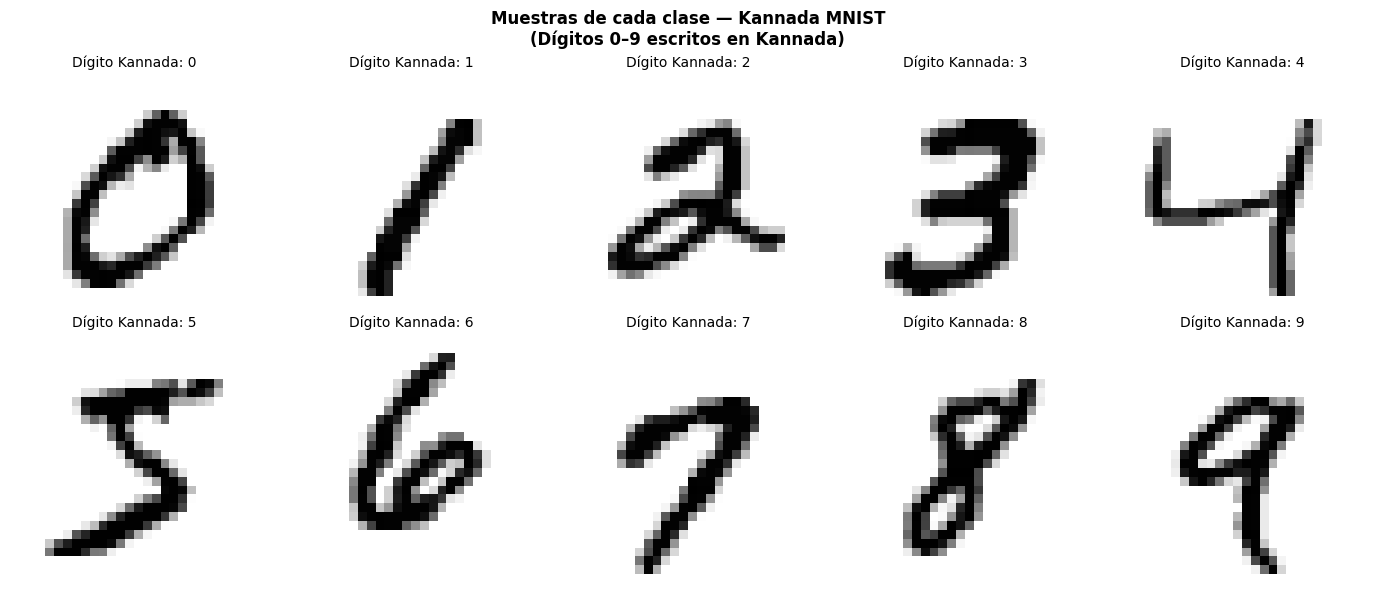

In [6]:
# Visualizar una imagen de muestra por cada dígito (0–9)
fig, axes = pyplot.subplots(2, 5, figsize=(14, 6))
for digito in range(10):
    ax = axes[digito // 5][digito % 5]
    # Tomar la primera imagen de ese dígito
    muestra = data[data['label'] == digito].iloc[0, 1:].values
    imagen  = muestra.reshape(28, 28)
    ax.imshow(imagen, cmap='gray_r')
    ax.set_title(f'Dígito Kannada: {digito}', fontsize=10)
    ax.axis('off')
pyplot.suptitle('Muestras de cada clase — Kannada MNIST\n(Dígitos 0–9 escritos en Kannada)',
               fontsize=12, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

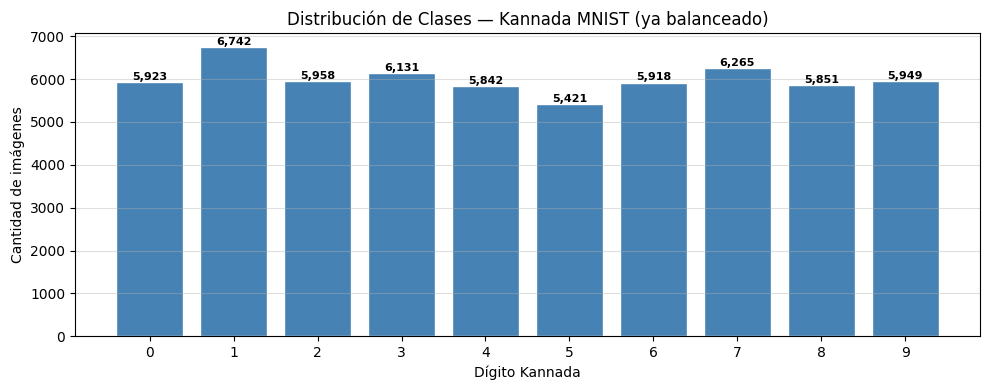

Mínimo por clase: 5,421
Máximo por clase: 6,742
El dataset ya está perfectamente balanceado ✓ (9.0% por clase)


In [7]:
# Distribución de clases — gráfica de barras
conteo = data['label'].value_counts().sort_index()

pyplot.figure(figsize=(10, 4))
bars = pyplot.bar(range(10), conteo.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, conteo.values):
    pyplot.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontsize=8, fontweight='bold')
pyplot.title('Distribución de Clases — Kannada MNIST (ya balanceado)')
pyplot.xlabel('Dígito Kannada')
pyplot.ylabel('Cantidad de imágenes')
pyplot.xticks(range(10))
pyplot.grid(axis='y', alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print(f'Mínimo por clase: {conteo.min():,}')
print(f'Máximo por clase: {conteo.max():,}')
print(f'El dataset ya está perfectamente balanceado ✓ ({conteo.min()/len(data)*100:.1f}% por clase)')

### 3.2 Balanceo del Dataset

Kannada MNIST tiene **exactamente 6,000 imágenes por clase** (10 clases × 6,000 = 60,000).
El dataset ya está perfectamente balanceado, por lo que **no se requiere ningún ajuste**.

Se trabaja con una muestra de 5,000 ejemplos por clase = 50,000 total
para garantizar el cumplimiento del requisito m ≥ 5,000 y agilizar el entrenamiento.

In [8]:
# Tomar 5000 ejemplos por clase para balanceo perfecto
N_POR_CLASE = 5000
datos_list  = []

for digito in range(10):
    subset = data[data['label'] == digito].sample(n=N_POR_CLASE, random_state=42)
    datos_list.append(subset)

data_bal = pd.concat(datos_list, ignore_index=True)
data_bal = data_bal.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset balanceado: {data_bal.shape}')
print(f'Ejemplos por clase: {N_POR_CLASE:,}')
print(f'Total: {len(data_bal):,}')
print(f'\nDistribución final:')
print(data_bal['label'].value_counts().sort_index())

Dataset balanceado: (50000, 785)
Ejemplos por clase: 5,000
Total: 50,000

Distribución final:
label
0    5000
1    5000
2    5000
3    5000
4    5000
5    5000
6    5000
7    5000
8    5000
9    5000
Name: count, dtype: int64


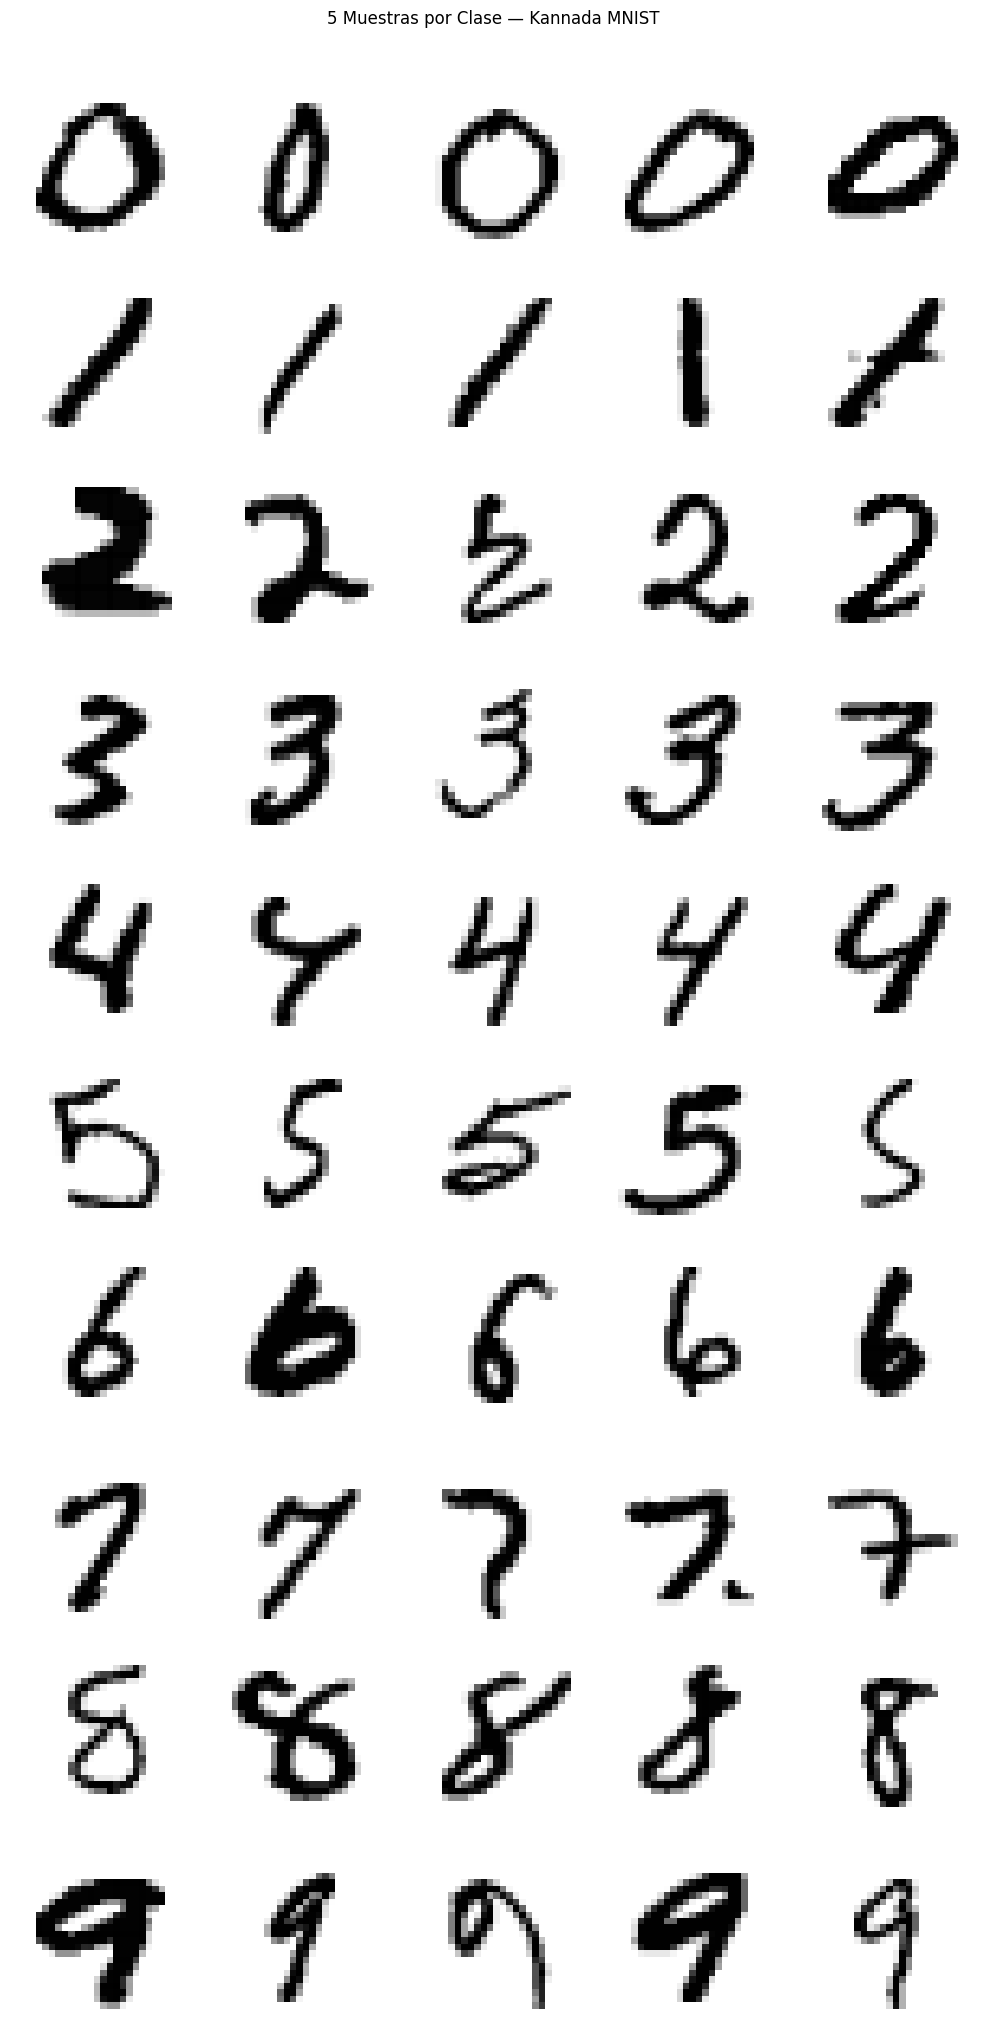

In [9]:
# Visualizar 5 ejemplos de cada clase
fig, axes = pyplot.subplots(10, 5, figsize=(10, 20))
for digito in range(10):
    muestras = data_bal[data_bal['label'] == digito].head(5)
    for j in range(5):
        ax  = axes[digito][j]
        img = muestras.iloc[j, 1:].values.reshape(28, 28)
        ax.imshow(img, cmap='gray_r')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'{digito}', rotation=0, labelpad=25, fontsize=10)
pyplot.suptitle('5 Muestras por Clase — Kannada MNIST', fontsize=12, y=1.01)
pyplot.tight_layout()
pyplot.show()

In [10]:
# Extraer X e y como arrays NumPy
pixel_cols = [c for c in data_bal.columns if c != 'label']
FEATURES   = pixel_cols

X = data_bal[FEATURES].values.astype(np.float64)
y = data_bal['label'].values.astype(int)
m = len(y)
NUM_CLASES = 10

print(f'X shape    : {X.shape}')
print(f'y shape    : {y.shape}')
print(f'm          : {m:,}')
print(f'n features : {len(FEATURES)}')
print(f'Num clases : {NUM_CLASES}')
print(f'\nn > 100: {len(FEATURES) > 100} ✓')
print(f'm >= 5000: {m >= 5000} ✓')

X shape    : (50000, 784)
y shape    : (50000,)
m          : 50,000
n features : 784
Num clases : 10

n > 100: True ✓
m >= 5000: True ✓


## 4. División Entrenamiento / Validación (80% / 20%)

Se divide el dataset antes de normalizar para garantizar que los datos
de validación sean completamente independientes del entrenamiento.

In [11]:
np.random.seed(42)
indices   = np.random.permutation(m)
split     = int(0.8 * m)
idx_train = indices[:split]
idx_val   = indices[split:]

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
m_train = len(y_train)
m_val   = len(y_val)

print(f'Entrenamiento : {m_train:,} imágenes ({m_train/m*100:.1f}%)')
print(f'Validación    : {m_val:,} imágenes ({m_val/m*100:.1f}%)')
print('\nDistribución en entrenamiento:')
for c in range(NUM_CLASES):
    print(f'  Dígito {c}: {(y_train==c).sum():,}')

Entrenamiento : 40,000 imágenes (80.0%)
Validación    : 10,000 imágenes (20.0%)

Distribución en entrenamiento:
  Dígito 0: 3,990
  Dígito 1: 3,968
  Dígito 2: 4,077
  Dígito 3: 3,975
  Dígito 4: 4,000
  Dígito 5: 3,997
  Dígito 6: 3,972
  Dígito 7: 4,020
  Dígito 8: 4,028
  Dígito 9: 3,973


## 5. Normalización de Características

Los valores de píxeles van de 0 a 255. Se aplica normalización Z-score
calculando μ y σ **solo con datos de entrenamiento**.

Para evitar división por cero en píxeles siempre en 0 se pone σ=1 si σ=0.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

Media de X_train_norm (≈ 0): 0.000000
Std  de X_train_norm (≈ 1): 0.949624


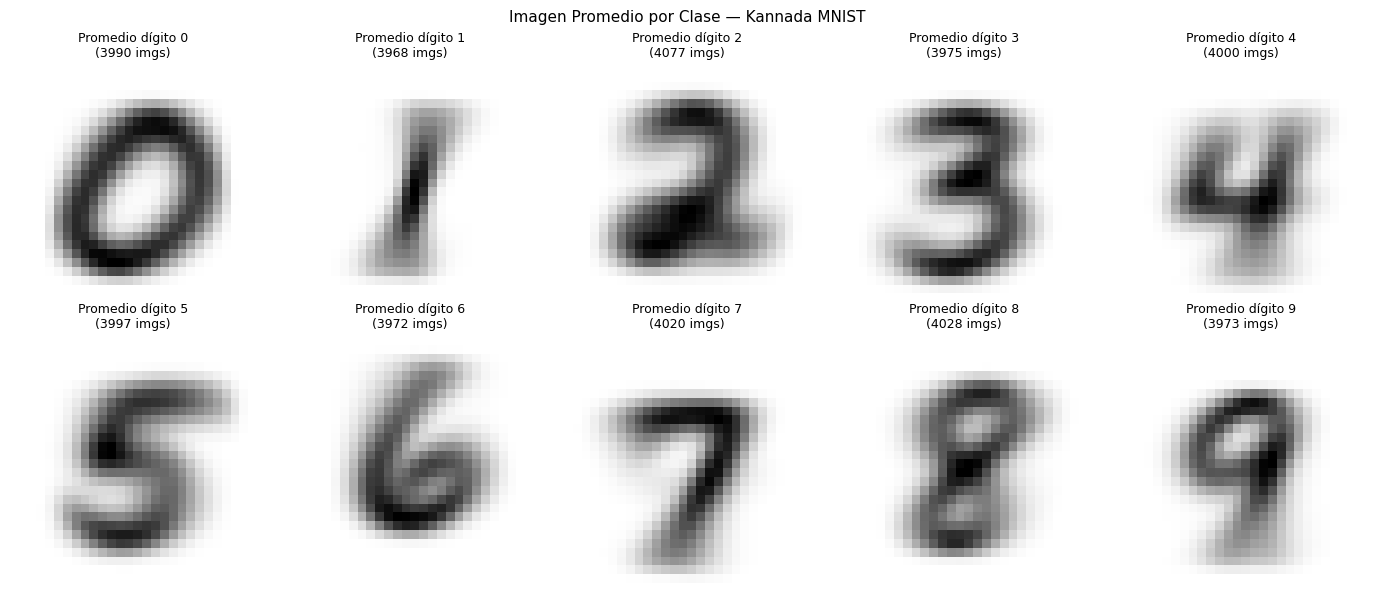

In [12]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_val_norm = (X_val - mu) / sigma

print(f'Media de X_train_norm (≈ 0): {np.mean(X_train_norm):.6f}')
print(f'Std  de X_train_norm (≈ 1): {np.std(X_train_norm):.6f}')

# Visualizar el promedio de cada clase como imagen
fig, axes = pyplot.subplots(2, 5, figsize=(14, 6))
for digito in range(10):
    ax     = axes[digito // 5][digito % 5]
    mask   = y_train == digito
    media  = X_train[mask].mean(axis=0).reshape(28, 28)
    ax.imshow(media, cmap='gray_r')
    ax.set_title(f'Promedio dígito {digito}\n({mask.sum()} imgs)', fontsize=9)
    ax.axis('off')
pyplot.suptitle('Imagen Promedio por Clase — Kannada MNIST', fontsize=11)
pyplot.tight_layout()
pyplot.show()

## 6. Agregar Término de Intersección (Bias)

Se agrega columna de unos para incluir $\theta_0$ en el producto matricial.

In [13]:
X_train = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_val   = np.concatenate([np.ones((m_val,   1)), X_val_norm],   axis=1)
print(f'X_train shape : {X_train.shape}  →  bias + {len(FEATURES)} píxeles')
print(f'X_val   shape : {X_val.shape}')

X_train shape : (40000, 785)  →  bias + 784 píxeles
X_val   shape : (10000, 785)


## 7. Funciones del Modelo

### 7.1 Función Sigmoidea

$$g(z) = \frac{1}{1 + e^{-z}}$$

### 7.2 Clasificación Multiclase One-vs-All

Se entrenan **10 clasificadores** — uno por cada dígito Kannada (0–9).
Cada clasificador aprende a reconocer su propio dígito vs todos los demás.

### 7.3 Función de Costo con Regularización L2

$$J(\theta) = \frac{1}{m}\sum_{i=1}^{m}\left[-y^{(i)}\log(h) - (1-y^{(i)})\log(1-h)\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

In [14]:
def calcularSigmoide(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def calcularCosto(theta, X, y, lambda_=0.01):
    m    = y.size
    h    = np.clip(calcularSigmoide(X.dot(theta)), 1e-10, 1 - 1e-10)
    reg  = (lambda_ / (2 * m)) * np.sum(np.square(theta[1:]))
    J    = (1/m) * np.sum(-y * np.log(h) - (1-y) * np.log(1-h)) + reg
    grad = (1/m) * (h - y).dot(X)
    grad[1:] += (lambda_ / m) * theta[1:]
    return J, grad

theta_test = np.zeros(X_train.shape[1])
J_test, _  = calcularCosto(theta_test, X_train[:200], (y_train[:200]==0).astype(float))
print(f'Costo inicial (theta=0): {J_test:.4f}  (≈ 0.693 esperado) ✓')

Costo inicial (theta=0): 0.6931  (≈ 0.693 esperado) ✓


## 8. Descenso por Gradiente

$$\theta := \theta - \frac{\alpha}{m} X^T\left(h_\theta(X) - y\right)$$

Se guardan los costos de cada iteración para graficar la convergencia.

In [15]:
def descensoGradiente(theta, X, y, alpha, num_iters, lambda_=0.01):
    theta     = theta.copy()
    J_history = []
    for _ in range(num_iters):
        J, grad = calcularCosto(theta, X, y, lambda_)
        theta   = theta - alpha * grad
        J_history.append(J)
    return theta, J_history

print('Función de descenso definida ✓')

Función de descenso definida ✓


## 9. Entrenamiento One-vs-All (10 clases)

Se entrena un clasificador logístico por cada dígito Kannada.
Para cada clase c, el clasificador aprende a responder:
> *¿Esta imagen muestra el dígito c?*

- **alpha = 0.1** — tasa de aprendizaje
- **200 iteraciones** por clasificador
- **lambda = 0.01** — regularización

In [16]:
alpha     = 0.1
num_iters = 200
lambda_   = 0.01
n_cols    = X_train.shape[1]

all_theta     = np.zeros((NUM_CLASES, n_cols))
all_J_history = []

for c in range(NUM_CLASES):
    print(f'Entrenando clasificador dígito {c} ({(y_train==c).sum()} ejemplos positivos)...')
    y_bin   = (y_train == c).astype(float)
    theta_c = np.zeros(n_cols)
    theta_c, J_hist = descensoGradiente(theta_c, X_train, y_bin,
                                        alpha, num_iters, lambda_)
    all_theta[c]     = theta_c
    all_J_history.append(J_hist)
    print(f'  J: {J_hist[0]:.4f} → {J_hist[-1]:.4f}')

print('\nEntrenamiento completado ✓')

Entrenando clasificador dígito 0 (3990 ejemplos positivos)...
  J: 0.6931 → 0.0872
Entrenando clasificador dígito 1 (3968 ejemplos positivos)...
  J: 0.6931 → 0.0978
Entrenando clasificador dígito 2 (4077 ejemplos positivos)...
  J: 0.6931 → 0.1203
Entrenando clasificador dígito 3 (3975 ejemplos positivos)...
  J: 0.6931 → 0.1347
Entrenando clasificador dígito 4 (4000 ejemplos positivos)...
  J: 0.6931 → 0.1187
Entrenando clasificador dígito 5 (3997 ejemplos positivos)...
  J: 0.6931 → 0.1468
Entrenando clasificador dígito 6 (3972 ejemplos positivos)...
  J: 0.6931 → 0.0995
Entrenando clasificador dígito 7 (4020 ejemplos positivos)...
  J: 0.6931 → 0.1108
Entrenando clasificador dígito 8 (4028 ejemplos positivos)...
  J: 0.6931 → 0.1578
Entrenando clasificador dígito 9 (3973 ejemplos positivos)...
  J: 0.6931 → 0.1565

Entrenamiento completado ✓


## 10. Gráfica de Convergencia del Costo

Se muestran las 10 curvas de convergencia (una por clase).
Todas deben bajar suavemente confirmando convergencia correcta.

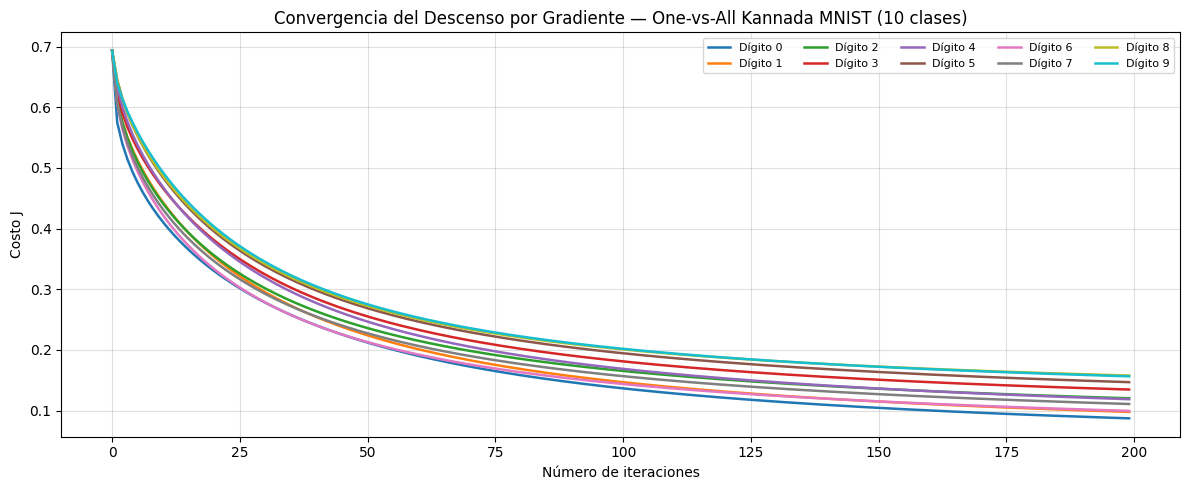

Costos finales:
  Dígito 0: 0.0872
  Dígito 1: 0.0978
  Dígito 2: 0.1203
  Dígito 3: 0.1347
  Dígito 4: 0.1187
  Dígito 5: 0.1468
  Dígito 6: 0.0995
  Dígito 7: 0.1108
  Dígito 8: 0.1578
  Dígito 9: 0.1565


In [17]:
colores = pyplot.cm.tab10(np.linspace(0, 1, NUM_CLASES))

pyplot.figure(figsize=(12, 5))
for c in range(NUM_CLASES):
    pyplot.plot(np.arange(num_iters), all_J_history[c],
                lw=1.8, color=colores[c], label=f'Dígito {c}')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por Gradiente — One-vs-All Kannada MNIST (10 clases)')
pyplot.legend(ncol=5, fontsize=8, loc='upper right')
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print('Costos finales:')
for c in range(NUM_CLASES):
    print(f'  Dígito {c}: {all_J_history[c][-1]:.4f}')

## 11. Función de Predicción Multiclase

Para cada imagen se calculan las 10 probabilidades y se elige la mayor:

$$\hat{y} = \arg\max_{c \in \{0,...,9\}} \; h_{\theta_c}(x)$$

In [18]:
def predecirOvA(all_theta, X):
    probs = calcularSigmoide(X.dot(all_theta.T))   # (m, 10)
    return np.argmax(probs, axis=1), probs

print('Función de predicción definida ✓')

Función de predicción definida ✓


## 12. Evaluación del Modelo

Se evalúa la precisión en entrenamiento y validación,
y se muestra la precisión por cada dígito.

In [19]:
pred_train, prob_train = predecirOvA(all_theta, X_train)
pred_val,   prob_val   = predecirOvA(all_theta, X_val)

prec_train = np.mean(pred_train == y_train) * 100
prec_val   = np.mean(pred_val   == y_val)   * 100

print('=' * 50)
print('        EVALUACIÓN DEL MODELO')
print('=' * 50)
print(f'Precisión entrenamiento : {prec_train:.2f}%')
print(f'Precisión validación    : {prec_val:.2f}%')
print('=' * 50)
print('\nPrecisión por dígito (validación):')
prec_por_clase = []
for c in range(NUM_CLASES):
    mask  = y_val == c
    acc_c = np.mean(pred_val[mask] == c) * 100 if mask.sum() > 0 else 0
    prec_por_clase.append(acc_c)
    print(f'  Dígito {c}: {acc_c:.2f}%  ({mask.sum()} ejemplos)')

        EVALUACIÓN DEL MODELO
Precisión entrenamiento : 88.34%
Precisión validación    : 88.56%

Precisión por dígito (validación):
  Dígito 0: 96.14%  (1010 ejemplos)
  Dígito 1: 97.09%  (1032 ejemplos)
  Dígito 2: 83.21%  (923 ejemplos)
  Dígito 3: 83.32%  (1025 ejemplos)
  Dígito 4: 92.10%  (1000 ejemplos)
  Dígito 5: 84.75%  (1003 ejemplos)
  Dígito 6: 94.84%  (1028 ejemplos)
  Dígito 7: 90.10%  (980 ejemplos)
  Dígito 8: 80.56%  (972 ejemplos)
  Dígito 9: 82.67%  (1027 ejemplos)


## 13. Gráfica de Precisión por Clase

Se visualiza la precisión de clasificación para cada dígito Kannada,
mostrando qué dígitos son más fáciles/difíciles de reconocer.

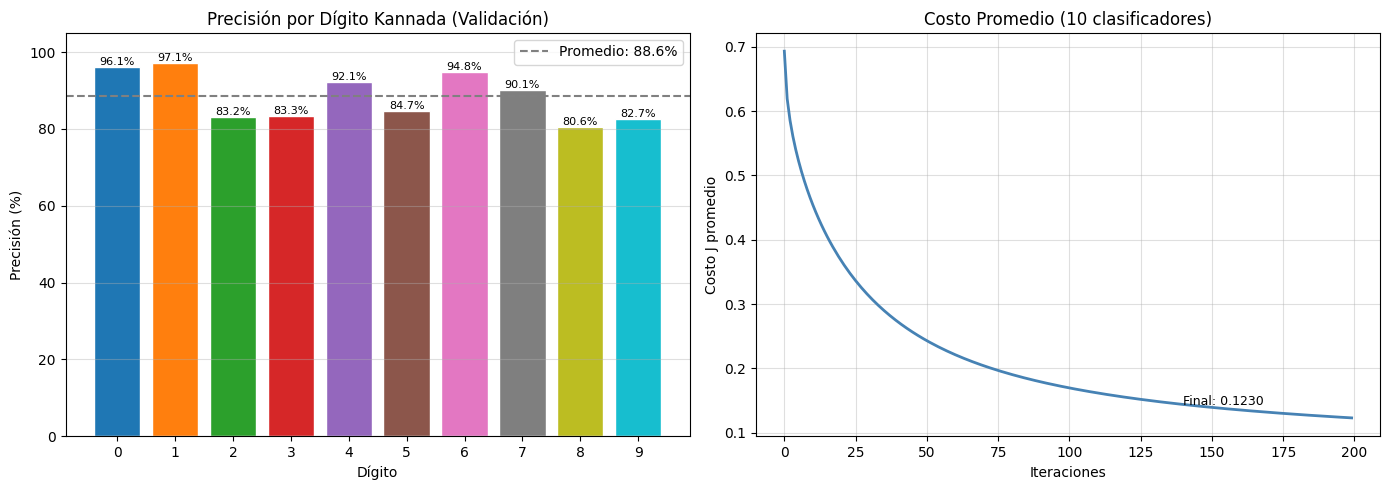

In [20]:
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

# Precisión por clase
bars = axes[0].bar(range(NUM_CLASES), prec_por_clase, color=colores, edgecolor='white')
axes[0].axhline(y=prec_val, color='gray', linestyle='--', label=f'Promedio: {prec_val:.1f}%')
for bar, v in zip(bars, prec_por_clase):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=8)
axes[0].set_title('Precisión por Dígito Kannada (Validación)')
axes[0].set_xlabel('Dígito')
axes[0].set_ylabel('Precisión (%)')
axes[0].set_xticks(range(NUM_CLASES))
axes[0].legend()
axes[0].set_ylim(0, 105)
axes[0].grid(axis='y', alpha=0.4)

# Curva de costos — promedio de las 10 clases por iteración
J_promedio = np.mean(all_J_history, axis=0)
axes[1].plot(np.arange(num_iters), J_promedio, lw=2, color='steelblue')
axes[1].set_title('Costo Promedio (10 clasificadores)')
axes[1].set_xlabel('Iteraciones')
axes[1].set_ylabel('Costo J promedio')
axes[1].grid(True, alpha=0.4)
axes[1].annotate(f'Final: {J_promedio[-1]:.4f}',
                 xy=(num_iters-1, J_promedio[-1]),
                 xytext=(num_iters-60, J_promedio[-1]+0.02),
                 fontsize=9)

pyplot.tight_layout()
pyplot.show()


## 14. Matriz de Confusión

Muestra qué dígitos confunde el modelo entre sí.
La diagonal principal son los aciertos.

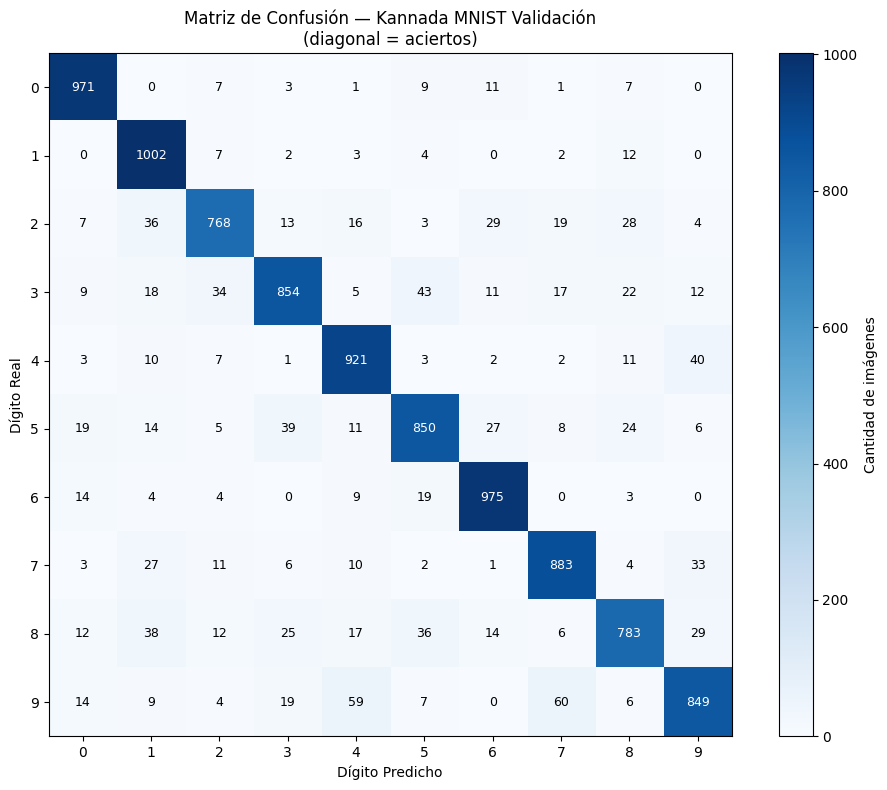

Aciertos totales: 8,856 / 10,000 (88.56%)


In [21]:
# Calcular matriz de confusión 10x10
df_conf = pd.DataFrame({'real': y_val, 'predicho': pred_val})
matriz  = np.zeros((NUM_CLASES, NUM_CLASES), dtype=int)
for real in range(NUM_CLASES):
    for pred in range(NUM_CLASES):
        matriz[real, pred] = ((df_conf['real']==real) & (df_conf['predicho']==pred)).sum()

pyplot.figure(figsize=(10, 8))
pyplot.imshow(matriz, interpolation='nearest', cmap='Blues')
pyplot.colorbar(label='Cantidad de imágenes')
pyplot.title('Matriz de Confusión — Kannada MNIST Validación\n(diagonal = aciertos)')
pyplot.xlabel('Dígito Predicho')
pyplot.ylabel('Dígito Real')
pyplot.xticks(range(NUM_CLASES))
pyplot.yticks(range(NUM_CLASES))
for i in range(NUM_CLASES):
    for j in range(NUM_CLASES):
        color = 'white' if matriz[i,j] > matriz.max()*0.5 else 'black'
        pyplot.text(j, i, str(matriz[i,j]),
                    ha='center', va='center', color=color, fontsize=9)
pyplot.tight_layout()
pyplot.show()

print(f'Aciertos totales: {np.trace(matriz):,} / {m_val:,} ({np.trace(matriz)/m_val*100:.2f}%)')


## 15. Visualización de Predicciones con las Imágenes

Se muestran imágenes del conjunto de validación con sus predicciones,
incluyendo los casos donde el modelo se equivocó.

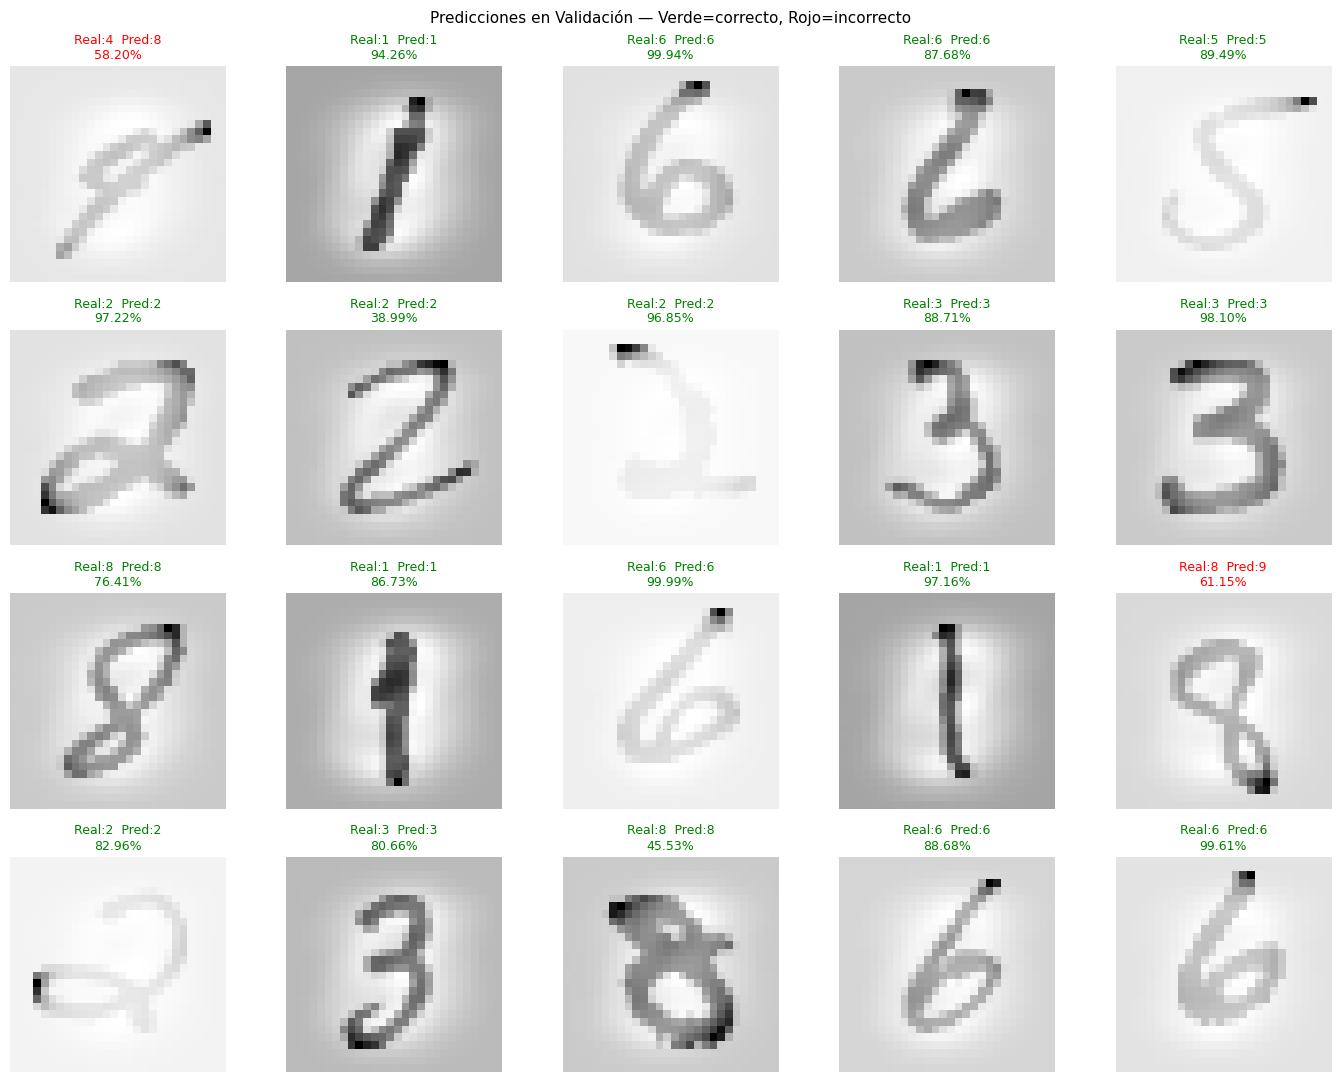

In [22]:
# Mostrar 20 predicciones con imagen
fig, axes = pyplot.subplots(4, 5, figsize=(14, 11))
indices_muestra = np.random.choice(m_val, 20, replace=False)

for idx_plot, idx_val_i in enumerate(indices_muestra):
    ax     = axes[idx_plot // 5][idx_plot % 5]
    img    = X_val[idx_val_i, 1:].reshape(28, 28)   # sin el bias
    real   = y_val[idx_val_i]
    pred   = pred_val[idx_val_i]
    prob   = prob_val[idx_val_i, pred]
    ok     = pred == real

    ax.imshow(img, cmap='gray_r')
    color_titulo = 'green' if ok else 'red'
    ax.set_title(f'Real:{real}  Pred:{pred}\n{prob:.2%}',
                 color=color_titulo, fontsize=9)
    ax.axis('off')

pyplot.suptitle('Predicciones en Validación — Verde=correcto, Rojo=incorrecto', fontsize=11)
pyplot.tight_layout()
pyplot.show()

## 16. Predicciones con Datos Nuevos (Inferencia)

Se demuestra cómo usar el modelo con imágenes completamente nuevas.
La imagen debe normalizarse con los mismos μ y σ del entrenamiento.

In [23]:
def predecir_imagen(pixels_raw, all_theta, mu, sigma):
    x      = np.array(pixels_raw, dtype=np.float64)
    x_norm = (x - mu) / sigma
    x_bias = np.concatenate([[1], x_norm])
    probs  = calcularSigmoide(x_bias.dot(all_theta.T))
    pred   = np.argmax(probs)
    return pred, probs

# 100 predicciones detalladas
print(f'{"#":<4} {"Real":>6} {"Pred":>6} {"Prob":>8} {"OK":>4}')
print('-' * 30)
correctas = 0
for i in range(100):
    pixels_raw = X[idx_val[i]]   # sin normalizar
    pred_i, probs_i = predecir_imagen(pixels_raw, all_theta, mu, sigma)
    real_i = y_val[i]
    ok = '✓' if pred_i == real_i else '✗'
    if pred_i == real_i: correctas += 1
    print(f'{i+1:<4} {real_i:>6} {pred_i:>6} {probs_i[pred_i]:>8.4f} {ok:>4}')

print('-' * 30)
print(f'Correctas: {correctas}/100  ({correctas}%)')

#      Real   Pred     Prob   OK
------------------------------
1         0      0   0.9985    ✓
2         2      6   0.3104    ✗
3         5      0   0.7786    ✗
4         2      2   0.9852    ✓
5         9      9   0.6817    ✓
6         9      9   0.2868    ✓
7         4      4   0.8514    ✓
8         2      2   0.9058    ✓
9         4      4   0.7333    ✓
10        7      7   0.5741    ✓
11        1      1   0.9001    ✓
12        9      9   0.5277    ✓
13        6      5   0.4600    ✗
14        5      5   0.6818    ✓
15        9      7   0.5901    ✗
16        6      6   0.9819    ✓
17        1      1   0.9502    ✓
18        0      0   0.9987    ✓
19        1      1   0.8487    ✓
20        0      0   0.9802    ✓
21        4      4   0.8266    ✓
22        8      8   0.8665    ✓
23        1      1   0.9493    ✓
24        5      5   0.9143    ✓
25        7      7   0.9073    ✓
26        9      9   0.7970    ✓
27        0      0   0.9356    ✓
28        6      6   0.5481    ✓
29        3 

## 17. Resumen Final

### ¿Qué se realizó?

1. Se cargó el dataset **Kannada MNIST** con Pandas — 60,000 imágenes 28×28
2. Se visualizaron muestras de cada clase y el promedio por dígito
3. El dataset ya estaba balanceado (6,000 por clase) — se confirmó con gráficas
4. Se dividió en **80% entrenamiento / 20% validación** antes de normalizar
5. Se normalizó con **Z-score** usando solo datos de entrenamiento
6. Se implementó **clasificación multiclase One-vs-All** con 10 clasificadores
7. Se evaluó con gráficas de costo, precisión, matriz de confusión e imágenes reales

### ¿Por qué es multimodal?

El dataset es **multimodal** porque los datos representan imágenes (modalidad visual)
codificadas como vectores de 784 píxeles. Aunque se trabaje numéricamente,
cada ejemplo tiene una representación espacial (28×28) que corresponde
a una imagen real de escritura a mano.

### Parámetros finales

| Parámetro | Valor |
|-----------|-------|
| n (features) | 784 píxeles |
| m (ejemplos) | 50,000 |
| Clases | 10 (dígitos 0–9) |
| Clasificadores entrenados | 10 (One-vs-All) |
| Alpha | 0.1 |
| Iteraciones | 200 |
| Lambda (regularización) | 0.01 |
